In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
# pip install pmdarima

In [3]:
import pmdarima as pm

In [4]:
df = pd.read_csv('airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [5]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
df['LogPassengers'] = np.log(df['Passengers'])

<Axes: xlabel='Month'>

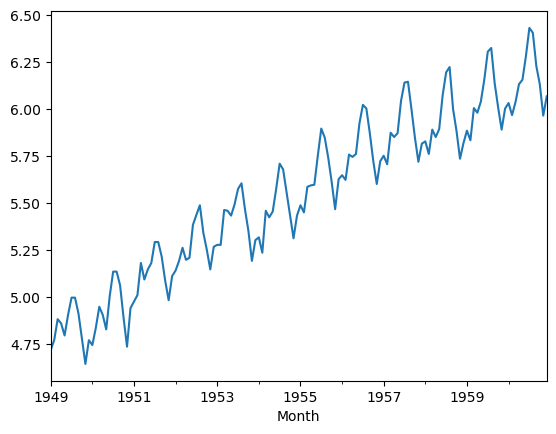

In [7]:
df['LogPassengers'].plot()

In [8]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [9]:
import pmdarima as pm

In [10]:
model = pm.auto_arima(train['Passengers'], 
                      trace = True, # to trace which models auto arima tests out to find the best model
                      suppress_warnings = True, # to suppress printing out the statsmodels warnings
                      seasonal = True, m = 12) # this is doing seasonal arima instead of vanilla arima
# m = 12 is like "p" - auto arima doesnt find this out automatically, since it will be compuationally very expensive - is it weekly, monthly, quarterly etc 

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=2.10 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.32 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.32 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.10 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=0.88 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.33 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.45 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=0.22 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=0.48 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.18 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=0.51 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC

In [11]:
# we know that seasonal period is 12

In [12]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Mon, 23 Mar 2026   AIC                            905.686
Time:                                    12:35:38   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
'''best model is ar(3) for the non seasonal part (3,0,0)
and for the seasonal part , it is just the 1st seasonal difference (0,1,0) - that is subtracting from 12 time steps behind'''

'best model is ar(3) for the non seasonal part (3,0,0)\nand for the seasonal part , it is just the 1st seasonal difference (0,1,0) - that is subtracting from 12 time steps behind'

In [14]:
''' this is much more simpler (parsimonious) model than just the vanilla arima we had earlier which was (12,1,0)'''
''' this seasonal arima just has 3 weights for last 3 data points and 1 intercept'''

' this seasonal arima just has 3 weights for last 3 data points and 1 intercept'

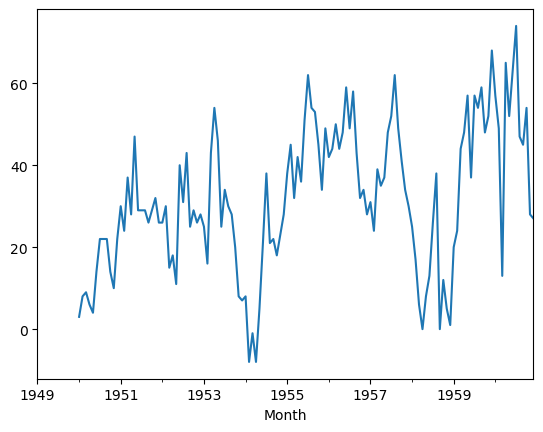

In [15]:
df['diff_12_behind'] = df['Passengers'].diff(periods=12)
df['diff_12_behind'].plot();

In [16]:
from statsmodels.tsa.stattools import adfuller

In [17]:
adfuller(df['diff_12_behind'].dropna())

(np.float64(-3.3830207264924805),
 np.float64(0.011551493085514982),
 1,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(919.527129208137))

In [18]:
''' clearly shows that test statistics is less than the 5% critical value and p value is also quite low 
- thus the diff between 12 time steps is stationary'''

' clearly shows that test statistics is less than the 5% critical value and p value is also quite low \n- thus the diff between 12 time steps is stationary'

In [19]:
df.tail()

,Passengers,LogPassengers,diff_12_behind
Month,,,
1960-08-01,606,6.406880,47.0
1960-09-01,508,6.230481,45.0
1960-10-01,461,6.133398,54.0
1960-11-01,390,5.966147,28.0
1960-12-01,432,6.068426,27.0


In [20]:
df.drop('diff_12_behind', axis = 1, inplace = True)

In [21]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

In [22]:
test_pred

1960-01-01    419.967172
1960-02-01    399.849851
1960-03-01    457.994382
1960-04-01    444.474156
1960-05-01    464.789179
1960-06-01    514.125441
1960-07-01    587.804170
1960-08-01    597.010823
1960-09-01    499.531269
1960-10-01    442.359679
1960-11-01    396.410217
1960-12-01    438.651596
Freq: MS, dtype: float64

In [23]:
conf_int

array([[400.26033126, 439.67401293],
       [375.73917341, 423.96052817],
       [429.66973494, 486.3190285 ],
       [414.00561744, 474.94269525],
       [432.79934779, 496.77901107],
       [481.23853812, 547.01234456],
       [554.32372777, 621.28461249],
       [563.16061654, 630.86102968],
       [465.44101183, 533.62152714],
       [408.11666902, 476.6026894 ],
       [362.06855187, 430.75188299],
       [404.24663789, 473.0565534 ]])

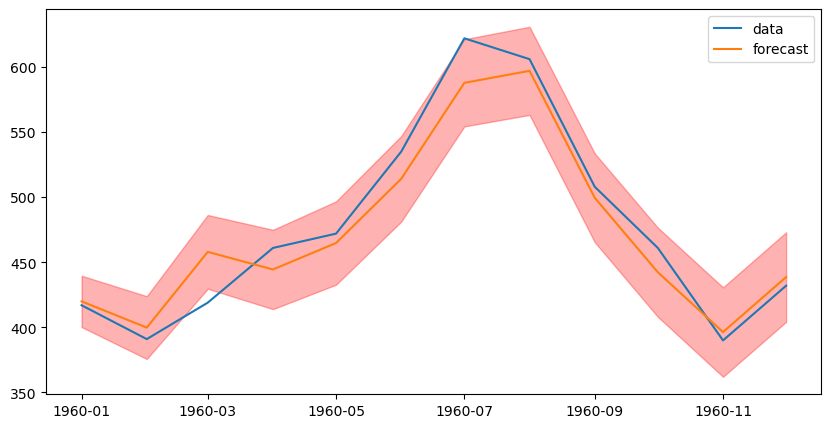

In [24]:
fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['Passengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()

In [25]:
''' forecast looks pretty good'''

' forecast looks pretty good'

In [26]:
train_pred =  model.predict_in_sample(start=0, end =-1)

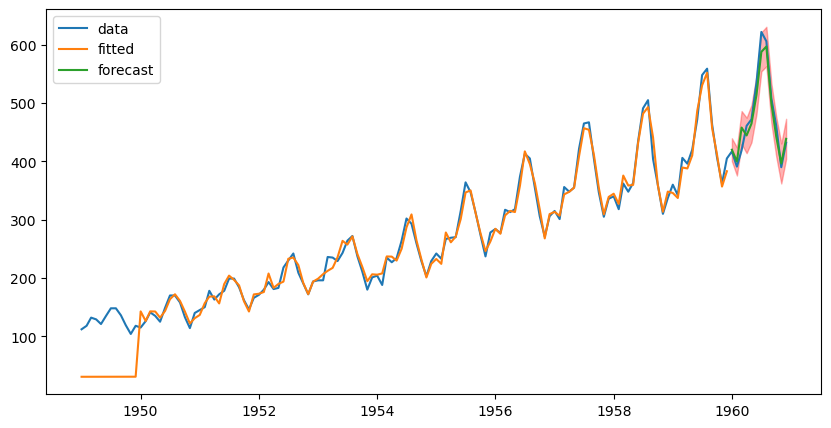

In [27]:
fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(df.index, df['Passengers'], label ='data')
ax.plot(train.index, train_pred, label = 'fitted')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend();

In [28]:
''' initially all 0s and flat points since its a seasonal model and not possible to make predictions for those points.
values needed for 1 season behind which is not possible initially'''

' initially all 0s and flat points since its a seasonal model and not possible to make predictions for those points.\nvalues needed for 1 season behind which is not possible initially'

In [50]:
## checking to see if model performs better on the log dataset
logmodel =  pm.auto_arima(train['LogPassengers'],
                          trace = True,
                          suppress_warnings = True,
                          seasonal = True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-438.269, Time=1.04 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-317.949, Time=0.08 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-433.027, Time=1.15 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-383.189, Time=0.52 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-134.983, Time=0.04 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=-444.327, Time=1.33 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=-414.783, Time=0.60 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=-442.330, Time=2.97 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=-436.715, Time=1.35 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=inf, Time=3.14 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-445.576, Time=1.26 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=-414.732, Time=0.41 sec
 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=-440.538, Time=1.42 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=-443.447, Time=3.02 sec
 ARIMA(1,0,2)(1,1,0)[12]

In [51]:
logmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  132
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 229.026
Date:                              Mon, 23 Mar 2026   AIC                           -448.052
Time:                                      12:48:43   BIC                           -434.114
Sample:                                  01-01-1949   HQIC                          -442.392
                                       - 12-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0194      0.009      2.167      0.030       0.002       0.037
ar.L1          0.5997      0.083      7.259      0.000       0.438       0.762
ar.L2          0.2410      0.085      2.845      0.004       0.075       0.407
ma.S.L12      -0.5664      0.105     -5.402      0.000      -0.772      -0.361
sigma2         0.0012      0.000      8.187      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.15
Prob(Q):                              1.00   Prob(JB):                         0.05
Heteroskedasticity (H):               0.36   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
''' 2 coefficients for auto regressive non seasonal arima and 1 coefficient for seasonal arima for MA.
differencing observed again in the seasonal arima and not in the vaniall arima part '''


' 2 coefficients for auto regressive non seasonal arima and 1 coefficient for seasonal arima for MA.\ndifferencing observed again in the seasonal arima and not in the vaniall arima part '

In [53]:
test_pred_log, confint = logmodel.predict(n_periods = Ntest, return_conf_int = True)
train_pred_log =  logmodel.predict_in_sample(start = 0, end =-1)

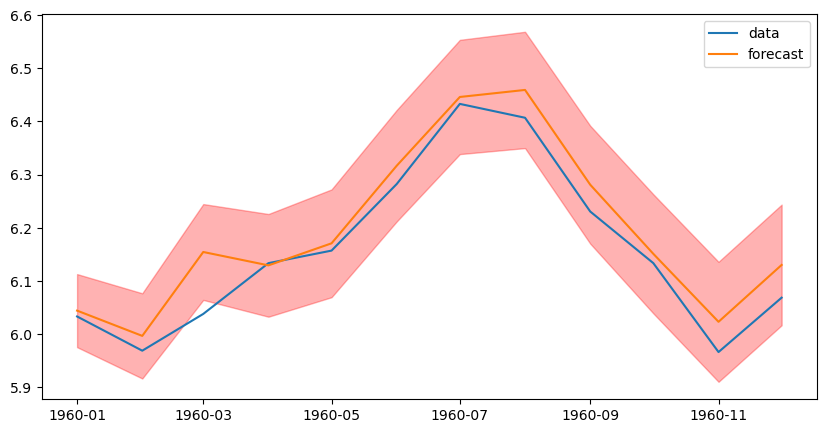

In [54]:
fig, ax = plt.subplots(figsize =(10,5))
ax.plot(test.index, test['LogPassengers'], label = 'data')
ax.plot(test.index, test_pred_log, label = 'forecast')
ax.fill_between(test.index, confint[:,0],confint[:,1], color = 'red', alpha = 0.3)
ax.legend();

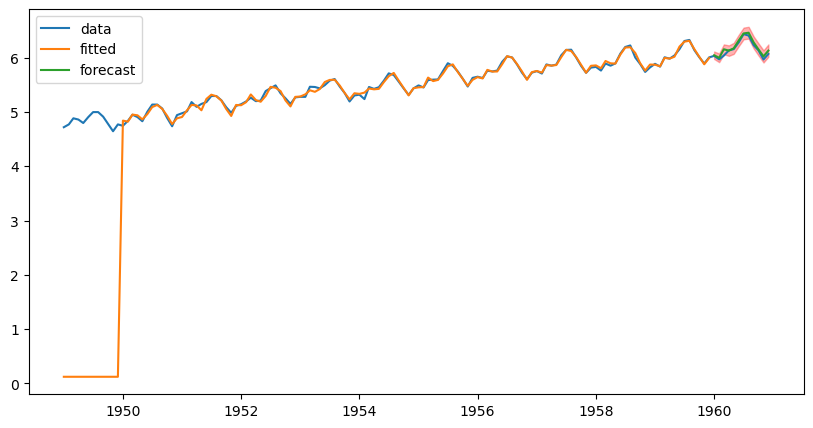

In [55]:
fig, ax = plt.subplots(figsize =(10,5))
ax.plot(df.index, df['LogPassengers'], label = 'data')
ax.plot(train.index, train_pred_log, label = 'fitted')
ax.plot(test.index, test_pred_log, label = 'forecast')
ax.fill_between(test.index, confint[:,0],confint[:,1], color = 'red', alpha = 0.3)
ax.legend();

### comparing both the models

In [56]:
def rmse(t,y):
    return np.sqrt(np.mean((t-y)**2))
    

In [57]:
print("non logged rmse", rmse(test['Passengers'],test_pred))
print("logged rmse", rmse(test['Passengers'],np.exp(test_pred_log)))

non logged rmse 18.536468706556747
logged rmse 23.053044098898535


In [58]:
''' no logged doing better which is surprising since we saw the opposite result when working with vanilla arima'''

' no logged doing better which is surprising since we saw the opposite result when working with vanilla arima'

#### non seasonal

In [74]:
model = pm.auto_arima(train['LogPassengers'],
                      trace = True,
                      suppress_warnings = True,
                      max_p = 12, max_q = 2, max_order = 14,
                      stepwise = True, # if set to false, then it would use grid search - this is default value as well
                      seasonal = False)
'''by default the max_p and max_q is set to 5 which is quite low - hence increasing it.
max_order by default is also set to 5. what it does is promotes parsimonious models.
max_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'''

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-240.135, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-211.983, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-214.718, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-216.493, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-212.867, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-246.402, Time=0.47 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-250.895, Time=0.51 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-227.139, Time=0.33 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-250.072, Time=0.62 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=-226.990, Time=0.62 sec
 ARIMA(4,1,2)(0,0,0)[0]             : AIC=-233.612, Time=0.44 sec

Best model:  ARIMA(4,1,2)(0,0,0)[0] intercept
T

'by default the max_p and max_q is set to 5 which is quite low - hence increasing it.\nmax_order by default is also set to 5. what it does is promotes parsimonious models.\nmax_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'

In [96]:
''' SEE ABOVE SEASOONAL COMPONENT OF ARIMA IS ALL SET TO 0'''

' SEE ABOVE SEASOONAL COMPONENT OF ARIMA IS ALL SET TO 0'

In [97]:
'''setting max_order = 14 since we are making it max_p + max_q.
also similarly, there are parameters max_P, max_Q, max_D for the seasonal parameters - default values for which are 2, 2 and 1 respectively.
IF WE CHANGED THE DEFAULT VALUE OF SEASONAL ARIMA AS WELL MAX_P, MAX_Q AND SET SEASONAL = TRUE, THIS WOULD JUST EXPLODE THE COMPUTATIONS CRAZILY.
SO BETTER TO DO IT IN CHUNKS
'''

'setting max_order = 14 since we are making it max_p + max_q.\nalso similarly, there are parameters max_P, max_Q, max_D for the seasonal parameters - default values for which are 2, 2 and 1 respectively.\nIF WE CHANGED THE DEFAULT VALUE OF SEASONAL ARIMA AS WELL MAX_P, MAX_Q AND SET SEASONAL = TRUE, THIS WOULD JUST EXPLODE THE COMPUTATIONS CRAZILY.\nSO BETTER TO DO IT IN CHUNKS\n'

In [98]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:              SARIMAX(12, 1, 2)   Log Likelihood                -494.031
Date:                Mon, 23 Mar 2026   AIC                           1020.062
Time:                        13:34:36   BIC                           1066.066
Sample:                    01-01-1949   HQIC                          1038.756
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.1064      3.022      2.021      0.043       0.183      12.030
ar.L1         -0.0767      0.143     -0.537      0.592      -0.357       0.203
ar.L2         -0.2992      0.142     -2.112      0.035      -0.577      -0.022
ar.L3         -0.1342      0.117     -1.150      0.250      -0.363       0.094
ar.L4         -0.2842      0.115     -2.481      0.013      -0.509      -0.060
ar.L5         -0.0921      0.116     -0.792      0.429      -0.320       0.136
ar.L6         -0.3052      0.112     -2.715      0.007      -0.526      -0.085
ar.L7         -0.1007      0.124     -0.814      0.415      -0.343       0.142
ar.L8         -0.3146      0.120     -2.623      0.009      -0.550      -0.080
ar.L9         -0.0836      0.120     -0.696      0.487      -0.319       0.152
ar.L10        -0.3178      0.129     -2.470      0.014      -0.570      -0.066
ar.L11        -0.0757      0.130     -0.584      0.559      -0.330       0.178
ar.L12         0.6367      0.126      5.061      0.000       0.390       0.883
ma.L1         -0.0959      0.157     -0.610      0.542      -0.404       0.212
ma.L2          0.2344      0.185      1.266      0.206      -0.129       0.597
sigma2        97.8928     15.342      6.381      0.000      67.822     127.963
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                13.03
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               1.86   Skew:                            -0.19
Prob(H) (two-sided):                  0.04   Kurtosis:                         4.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

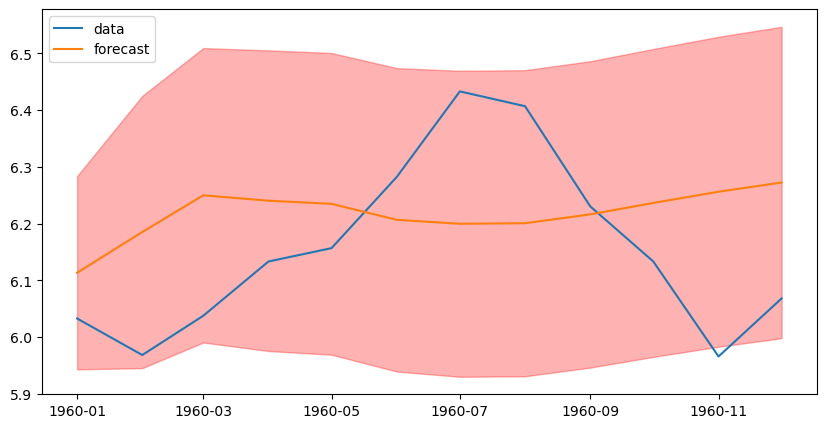

In [77]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['LogPassengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()

In [78]:
'''pretty bad model'''

'pretty bad model'

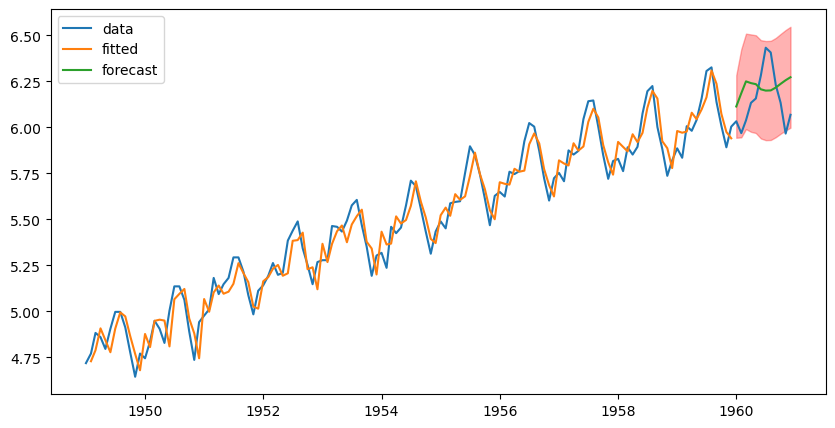

In [79]:
train_pred =  model.predict_in_sample(start=1, end =-1)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(df.index, df['LogPassengers'], label ='data')
ax.plot(train.index[1:], train_pred, label = 'fitted')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend();

In [80]:
rmse(test['Passengers'], np.exp(test_pred))

np.float64(83.90191084584188)

#### performing grid search on non seasonal

In [81]:
model = pm.auto_arima(train['LogPassengers'],
                      trace = True,
                      suppress_warnings = True,
                      max_p = 12, max_q = 2, max_order = 14,
                      stepwise = False, # if set to false, then it would use grid search - this is default value as well
                      seasonal = False)
'''by default the max_p and max_q is set to 5 which is quite low - hence increasing it.
max_order by default is also set to 5. what it does is promotes parsimonious models.
max_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'''

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-211.983, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-216.493, Time=0.20 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-214.718, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-221.069, Time=0.14 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-216.622, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-240.135, Time=0.42 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-216.024, Time=0.13 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-246.402, Time=0.49 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-229.057, Time=0.29 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-227.139, Time=0.35 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-250.895, Time=0.55 sec
 ARIMA(5,1,0)(0,0,0)[0] interc

'by default the max_p and max_q is set to 5 which is quite low - hence increasing it.\nmax_order by default is also set to 5. what it does is promotes parsimonious models.\nmax_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'

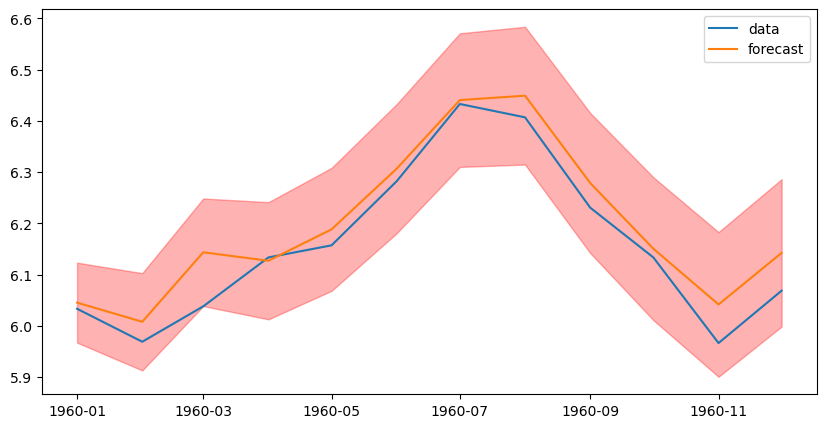

In [82]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['LogPassengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()

In [83]:
''' looks pretty good - this shows that we cant fully rely on stepwise doing the job properly
running grid search does a thorough search AND also in this , we are seeing that p value in non seasonal component of above is reaching
till 12 compared to just 5 when running stepwise
'''

' looks pretty good - this shows that we cant fully rely on stepwise doing the job properly\nrunning grid search does a thorough search AND also in this , we are seeing that p value in non seasonal component of above is reaching\ntill 12 compared to just 5 when running stepwise\n'

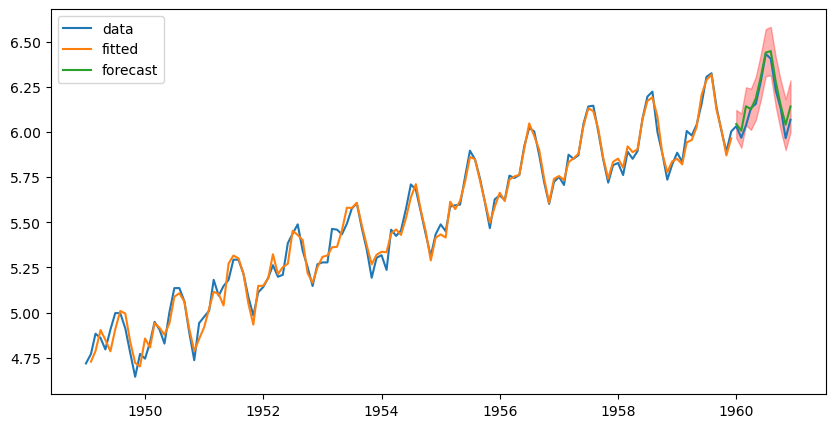

In [84]:
train_pred =  model.predict_in_sample(start=1, end =-1)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(df.index, df['LogPassengers'], label ='data')
ax.plot(train.index[1:], train_pred, label = 'fitted')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend();

In [85]:
rmse(test['Passengers'], np.exp(test_pred))

np.float64(22.867957620992964)

In [87]:
'''the above is worse than non logged seasonal but slightly better than seasonal logged'''

'the above is worse than non logged seasonal but slightly better than seasonal logged'

In [88]:
model = pm.auto_arima(train['Passengers'],
                      trace = True,
                      suppress_warnings = True,
                      max_p = 12, max_q = 2, max_order = 14,
                      stepwise = True, # if set to false, then it would use grid search - this is default value as well
                      seasonal = False)
'''by default the max_p and max_q is set to 5 which is quite low - hence increasing it.
max_order by default is also set to 5. what it does is promotes parsimonious models.
max_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'''

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1218.683, Time=0.46 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1277.589, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1268.313, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1264.738, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1276.259, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1258.440, Time=0.15 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1225.563, Time=0.37 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] intercept
Total fit time: 2.870 seconds


'by default the max_p and max_q is set to 5 which is quite low - hence increasing it.\nmax_order by default is also set to 5. what it does is promotes parsimonious models.\nmax_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'

In [89]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)
rmse(test['Passengers'], test_pred)

np.float64(53.290501081705145)

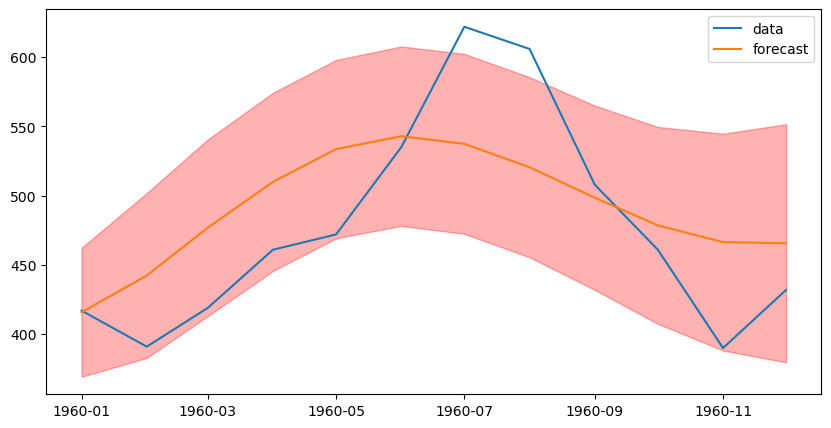

In [90]:
''' this is not good'''
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['Passengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()

In [91]:
model = pm.auto_arima(train['Passengers'],
                      trace = True,
                      suppress_warnings = True,
                      max_p = 12, max_q = 2, max_order = 14,
                      stepwise = False, # if set to false, then it would use grid search - this is default value as well
                      seasonal = False)
'''by default the max_p and max_q is set to 5 which is quite low - hence increasing it.
max_order by default is also set to 5. what it does is promotes parsimonious models.
max_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'''

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1277.589, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1264.738, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1262.608, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1268.313, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1258.440, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1263.896, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1218.683, Time=0.62 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1261.216, Time=0.18 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=1254.439, Time=0.25 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=1245.588, Time=0.48 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept  

'by default the max_p and max_q is set to 5 which is quite low - hence increasing it.\nmax_order by default is also set to 5. what it does is promotes parsimonious models.\nmax_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'

In [92]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)
rmse(test['Passengers'], test_pred)

np.float64(20.14921591306852)

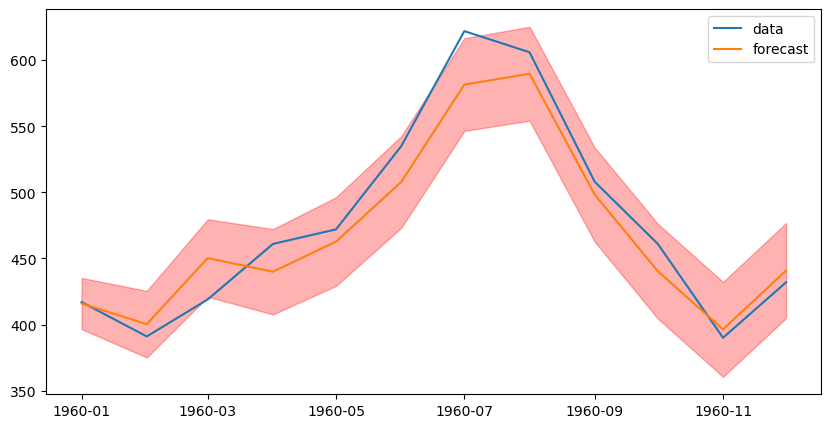

In [94]:
''' this is still not beating the non logged seasonal arima'''
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['Passengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()

## conclusion

In [1]:
''' best performing model was seasonal non logged arima.
remnoving the seasonal arima and running vanilla arima was not able to beat the seasonal arima proving that seasonal arima 
improves the model performance'''
''' ALSO NOTE THAT AUTO ARIMA TRIES TO FIND THE LEAST AIC WHICH PROMOTES PARSIMONIOUSITYM , WHICH DOESNT NECESSARILY MEAN THAT ACCURACY/RMSE WILL 
BE THE BEST FOR MODEL WITH LEAST AIC'''

' ALSO NOTE THAT AUTO ARIMA TRIES TO FIND THE LEAST AIC WHICH PROMOTES PARSIMONIOUSITYM , WHICH DOESNT NECESSARILY MEAN THAT ACCURACY/RMSE WILL \nBE THE BEST FOR MODEL WITH LEAST AIC'

### performing step wise search with seasonality turned on

In [103]:
model = pm.auto_arima(train['Passengers'],
                      trace = True,
                      suppress_warnings = True,
                      max_p = 12, max_q = 2, max_order = 14,
                      stepwise = True, # if set to false, then it would use grid search - this is default value as well
                      seasonal = True, m=12)
'''by default the max_p and max_q is set to 5 which is quite low - hence increasing it.
max_order by default is also set to 5. what it does is promotes parsimonious models.
max_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'''

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.52 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.30 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.30 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.12 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=0.85 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.31 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.57 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=0.20 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=0.45 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.12 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=0.32 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC

'by default the max_p and max_q is set to 5 which is quite low - hence increasing it.\nmax_order by default is also set to 5. what it does is promotes parsimonious models.\nmax_order = p+q+P+Q - max_order ensures that the sum doesnt exceed max_order'

In [101]:
''' if we had set seasonality = true and not provided m=12 parameter, it would have assumed non seasonal arima'''

' if we had set seasonality = true and not provided m=12 parameter, it would have assumed non seasonal arima'

In [104]:
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)
rmse(test['Passengers'], test_pred)

np.float64(18.536468706556747)

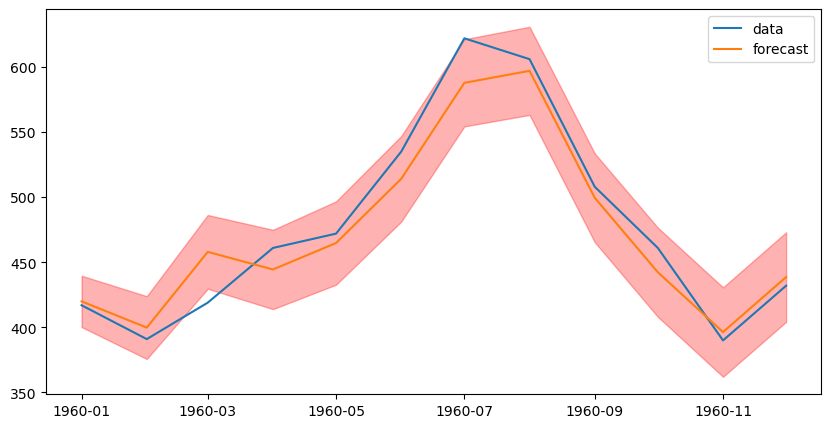

In [105]:
''' this is still not beating the non logged seasonal arima'''
test_pred, conf_int = model.predict(n_periods = Ntest, return_conf_int = True)

fig, ax  = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['Passengers'], label ='data')
ax.plot(test.index, test_pred, label = 'forecast')
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color = 'red', alpha = 0.3)
ax.legend()